# CycleGAN for Unpaired Face Sketch-to-Photo Translation

## 1. Introduction

This project focuses on translating unpaired face sketches into realistic face photographs using CycleGAN, implemented in TensorFlow. CycleGAN enables image-to-image translation without the need for paired training data by learning the relationship between two visual domains—sketches and photos—through adversarial learning and cycle-consistency constraints. The framework uses two generators and two discriminators to ensure that the translated images look realistic and that the original inputs can be accurately reconstructed. The goal of this project is to show how unpaired data can still produce effective sketch-to-photo and photo-to-sketch conversions while exploring the architecture, training process, and performance of CycleGAN within the TensorFlow ecosystem.

## 2. Dataset Description

### 2.1 Source of the Dataset

The dataset used in this project is sourced from Kaggle, and the original images are derived from the CelebAMask-HQ dataset. The images selected for this project exclude samples with the following attributes:
	•	Eyeglasses
	•	Wearing_Hat
	•	Facial angles where Yaw, Pitch, or Raw absolute degrees are greater than 20

This filtering ensures a clean, front-facing set of face images suitable for sketch-to-photo translation.

### 2.2 Photo Domain (Domain A)

Domain A contains high-quality face photographs. These images come from the filtered CelebAMask-HQ dataset and consist of 679 photo samples in the test set, with thousands more in the training and validation splits. Each image is clear, front-facing, and free from major occlusions, making it ideal for translation tasks.

### 2.3 Sketch Domain (Domain B)

Domain B consists of rough face sketches generated programmatically from the corresponding photos. The sketches are created through the following sequential transformations:
* ImageFilter.FIND_EDGES
* ImageFilter.BLUR
* ImageFilter.SHARPEN
* ImageOps.invert()
* ImageEnhance.Contrast().enhance(1.5)

After generating rough edge maps, the images undergo Sketch Simplification, producing cleaner and more structured sketch-style representations. This gives the dataset a realistic sketch domain suitable for CycleGAN training.

### 2.4 Loading Dataset

In [10]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow as tf

tf.config.run_functions_eagerly(True)
print("Eager execution:", tf.executing_eagerly())

# Set dataset paths
TRAIN_PHOTOS = 'dataset/train/photos'
TRAIN_SKETCHES = 'dataset/train/sketches'
TEST_PHOTOS = 'dataset/test/photos'
TEST_SKETCHES = 'dataset/test/sketches'
VAL_PHOTOS = 'dataset/val/photos'
VAL_SKETCHES = 'dataset/val/sketches'

Eager execution: True


## 3. Data Preprocessing

### 3.1 Image Transformations Used
* The raw images come in different resolutions.
* We resize every image to 64×64 using tf.image.resize().
* A fixed input size is needed for the ResNet-based Generator.
* Higher sizes like 512×512 use more VRAM and slow the process.

In [11]:
IMG_HEIGHT = 64
IMG_WIDTH = 64

def img_tranformation(img):
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    return img

### 3.2 Normalization
* We normalize pixel values from the standard range of [0, 255] to the range [-1, 1].

In [12]:
def img_norm(img):
    img = tf.cast(img, tf.float32)/255.0
    return img

### 3.3 Augmentation
* A horizontally flipped face is still a valid face. This effectively doubles our training data and forces the model to learn features (like eyes, nose structure) regardless of their specific left/right orientation.

In [13]:
def augmentation(img):
    img = tf.image.random_flip_left_right(img)
    return img

### 3.4 Preprocess and Visualisation

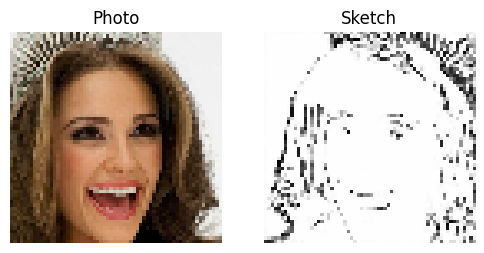

In [14]:
def preprocess_image(path):
    img = tf.io.read_file(path)
    img = img_tranformation(img)
    img = img_norm(img)
    img = augmentation(img)
    return img

# Get sorted file lists for reproducibility
photo_files = sorted([os.path.join(TRAIN_PHOTOS, f) for f in os.listdir(TRAIN_PHOTOS) if f.endswith(('.jpg', '.jpeg', '.png'))])
sketch_files = sorted([os.path.join(TRAIN_SKETCHES, f) for f in os.listdir(TRAIN_SKETCHES) if f.endswith(('.jpg', '.jpeg', '.png'))])

# Load the first pair
photo_img = preprocess_image(photo_files[0])
sketch_img = preprocess_image(sketch_files[0])

# Display the pair
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(photo_img)
plt.title("Photo")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(sketch_img, cmap='gray')
plt.title("Sketch")
plt.axis('off')
plt.show()

In [15]:
# Create tf.data.Dataset objects for photos and sketches
photo_ds = tf.data.Dataset.from_tensor_slices(photo_files)
sketch_ds = tf.data.Dataset.from_tensor_slices(sketch_files)

# Map preprocessing to both datasets
photo_ds = photo_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
sketch_ds = sketch_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

# Zip the datasets together for paired training
train_dataset = tf.data.Dataset.zip((photo_ds, sketch_ds)).shuffle(1000).batch(1)

/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


## 4. CycleGAN Architecture

### 4.1 Custom Layers & Blocks

These helper functions define the repetitive building blocks used to construct the larger networks:

**4.11: InstanceNormalisation Class:** InstanceNormalization is a layer that normalises each image individually to preserve its unique style—unlike Batch Normalisation—and works by learning scale and offset parameters, computing per-image spatial mean and variance, standardising the input, and then applying the learned re-scaling and shifting.

In [6]:
import keras
import keras.layers as layers

class InstanceNormalization(layers.Layer):
    def __init__(self, epsilon=1e-5, **kwargs):
        super().__init__(**kwargs)       
        self.epsilon = epsilon

    def build(self, input_shape):
        self.scale = self.add_weight(
            name='scale', shape=input_shape[-1:],
            initializer=tf.random_normal_initializer(1., 0.02), trainable=True)
        self.offset = self.add_weight(
            name='offset', shape=input_shape[-1:],
            initializer='zeros', trainable=True)

    def call(self, x):
        mean, variance = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        inv = tf.math.rsqrt(variance + self.epsilon)
        normalized = (x - mean) * inv
        return self.scale * normalized + self.offset

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"epsilon": self.epsilon})
        return cfg

**4.12: Down Sample Function**: A downsampling block reduces the image’s height and width while increasing feature depth by using a stride-2 convolution without bias (since normalization handles offsets) followed by a LeakyReLU activation to maintain stable gradients.

In [8]:
def downsample(filters, size, apply_instancenorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = keras.Sequential()
    result.add(layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))
    if apply_instancenorm:
        result.add(InstanceNormalization())
    result.add(layers.LeakyReLU())
    return result

**4.13: Up Sample Function**: An upsampling block increases the image resolution using a Conv2DTranspose layer, followed by InstanceNormalization and a 50% Dropout to add essential randomness that prevents the model from memorising the training data.

In [9]:
def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = keras.Sequential()
    result.add(layers.Conv2DTranspose(filters, size, strides=2, padding='same',
                                      kernel_initializer=initializer, use_bias=False))
    result.add(InstanceNormalization())
    if apply_dropout:
        result.add(layers.Dropout(0.5))
    result.add(layers.ReLU())
    return result

### 4.2 Generator (ResNet Based)

**4.21: Residual Block**: A residual_block lets the network learn small corrections by processing the input through two Conv + InstanceNorm layers and then adding the original input back through a skip connection.


In [10]:
def residual_block(x):
    initializer = tf.random_normal_initializer(0., 0.02)
    dim = x.shape[-1]
    
    skip = x
    
    x = layers.Conv2D(dim, 3, padding='same', kernel_initializer=initializer, use_bias=False)(x)
    x = InstanceNormalization()(x)
    x = layers.ReLU()(x)
    
    x = layers.Conv2D(dim, 3, padding='same', kernel_initializer=initializer, use_bias=False)(x)
    x = InstanceNormalization()(x)
    
    return layers.Add()([x, skip])

**4.22: Build Generator Function**:
* In the **encoding phase**, the generator takes a 256×256×3 image, applies an initial convolution to produce 64 channels, and then uses two downsampling blocks to reduce the resolution to 128×128 and 64×64 while increasing feature depth to 256, effectively compressing the image into high-level representations.

* In the **transformation phase**, the generator applies nine residual blocks at the 64×64 bottleneck, modifying texture and color while preserving structure through skip connections.
    
* In the **decoding phase**, the generator uses two upsampling blocks to restore the image to 128×128 and then 256×256, followed by a final convolution that outputs 3 RGB channels with a tanh activation to produce pixel values in the [-1, 1] range.

ResNet is used because its skip connections preserve the image’s structural information while enabling texture changes, preventing vanishing gradients and helping the generator maintain the original object’s identity.

In [11]:
def build_generator():
    inputs = layers.Input(shape=[64, 64, 3])  # Change input shape to 64x64x3

    # 1. Encoder
    x = layers.Conv2D(64, 7, strides=1, padding='same',
                      kernel_initializer=tf.random_normal_initializer(0., 0.02), use_bias=False)(inputs)
    x = InstanceNormalization()(x)
    x = layers.ReLU()(x)

    x = downsample(128, 3)(x)  # 64x64 -> 32x32
    x = downsample(256, 3)(x)  # 32x32 -> 16x16

    # 2. Transformer (Residual Blocks)
    for _ in range(6):  # 6 blocks for 64x64 images (fewer than for 256x256)
        x = residual_block(x)

    # 3. Decoder
    x = upsample(128, 3)(x)    # 16x16 -> 32x32
    x = upsample(64, 3)(x)     # 32x32 -> 64x64

    # Output
    x = layers.Conv2D(3, 7, strides=1, padding='same',
                      kernel_initializer=tf.random_normal_initializer(0., 0.02), activation='tanh')(x)

    return keras.Model(inputs=inputs, outputs=x)

### 4.3 Discriminator (PatchGAN)

The discriminator uses a PatchGAN architecture that downsamples a 256×256 image through several convolutional blocks and outputs a feature map where each pixel represents the realism of a local 36×36 patch, rather than producing a single real/fake score. This design focuses on high-frequency details and encourages the generator to produce sharper, more realistic textures across the entire image.

In [12]:
def build_discriminator():
    initializer = tf.random_normal_initializer(0., 0.02)
    inputs = layers.Input(shape=[64, 64, 3], name='input_image')

    x = downsample(64, 4, False)(inputs)   # (32, 32, 64)
    x = downsample(128, 4)(x)              # (16, 16, 128)
    x = downsample(256, 4)(x)              # (8, 8, 256)

    # Zero Pad and Conv
    x = layers.ZeroPadding2D()(x)
    x = layers.Conv2D(512, 4, strides=1, kernel_initializer=initializer, use_bias=False)(x)
    x = InstanceNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.ZeroPadding2D()(x)
    x = layers.Conv2D(1, 4, strides=1, kernel_initializer=initializer)(x)  # Output 1 channel prediction

    return keras.Model(inputs=inputs, outputs=x)

## 5. The CycleGAN Model Class

In [14]:
# Updated CycleGan class (replacement for older cell). Use four separate optimizers for G and F, and for D_x and D_y.
class CycleGan(keras.Model):
    def __init__(self, generator_G, generator_F, discriminator_X, discriminator_Y, lambda_cycle=10.0, lambda_identity=5.0):
        super().__init__()
        self.gen_G = generator_G
        self.gen_F = generator_F
        self.disc_X = discriminator_X
        self.disc_Y = discriminator_Y
        self.lambda_cycle = lambda_cycle
        self.lambda_identity = lambda_identity

    def compile(self, d_optimizer_X, d_optimizer_Y, g_optimizer_G, g_optimizer_F, gen_loss_fn, disc_loss_fn, cycle_loss_fn, identity_loss_fn):
        super().compile()
        self.d_optimizer_X = d_optimizer_X
        self.d_optimizer_Y = d_optimizer_Y
        self.g_optimizer_G = g_optimizer_G
        self.g_optimizer_F = g_optimizer_F
        self.gen_loss_fn = gen_loss_fn
        self.disc_loss_fn = disc_loss_fn
        self.cycle_loss_fn = cycle_loss_fn
        self.identity_loss_fn = identity_loss_fn

    def train_step(self, batch_data):
        real_x, real_y = batch_data
        with tf.GradientTape(persistent=True) as tape:
            fake_y = self.gen_F(real_x, training=True)
            fake_x = self.gen_G(real_y, training=True)

            cycled_x = self.gen_G(fake_y, training=True)
            cycled_y = self.gen_F(fake_x, training=True)

            same_x = self.gen_G(real_x, training=True)
            same_y = self.gen_F(real_y, training=True)

            disc_real_x = self.disc_X(real_x, training=True)
            disc_fake_x = self.disc_X(fake_x, training=True)

            disc_real_y = self.disc_Y(real_y, training=True)
            disc_fake_y = self.disc_Y(fake_y, training=True)

            gen_G_loss = self.gen_loss_fn(disc_fake_x)
            gen_F_loss = self.gen_loss_fn(disc_fake_y)

            total_cycle_loss = self.cycle_loss_fn(real_x, cycled_x) + self.cycle_loss_fn(real_y, cycled_y)
            total_identity_loss = self.identity_loss_fn(real_x, same_x) + self.identity_loss_fn(real_y, same_y)

            total_gen_G_loss = gen_G_loss + (total_cycle_loss * self.lambda_cycle) + (total_identity_loss * self.lambda_identity)
            total_gen_F_loss = gen_F_loss + (total_cycle_loss * self.lambda_cycle) + (total_identity_loss * self.lambda_identity)

            disc_X_loss = self.disc_loss_fn(disc_real_x, disc_fake_x)
            disc_Y_loss = self.disc_loss_fn(disc_real_y, disc_fake_y)

        grads_G = tape.gradient(total_gen_G_loss, self.gen_G.trainable_variables)
        grads_F = tape.gradient(total_gen_F_loss, self.gen_F.trainable_variables)

        disc_X_vars = self.disc_X.trainable_variables
        disc_Y_vars = self.disc_Y.trainable_variables
        grads_disc_X = tape.gradient(disc_X_loss, disc_X_vars)
        grads_disc_Y = tape.gradient(disc_Y_loss, disc_Y_vars)

        self.g_optimizer_G.apply_gradients(zip(grads_G, self.gen_G.trainable_variables))
        self.g_optimizer_F.apply_gradients(zip(grads_F, self.gen_F.trainable_variables))
        self.d_optimizer_X.apply_gradients(zip(grads_disc_X, disc_X_vars))
        self.d_optimizer_Y.apply_gradients(zip(grads_disc_Y, disc_Y_vars))

        return {"G_loss": total_gen_G_loss, "F_loss": total_gen_F_loss, "D_X_loss": disc_X_loss, "D_Y_loss": disc_Y_loss}

## 6. Loss Functions & Initialization

In [16]:
# Updated Model + Optimizer initialization (replacement):
# Build models
gen_G = build_generator()  # Sketch -> Photo
gen_F = build_generator()  # Photo -> Sketch
disc_X = build_discriminator()  # Photo Classifier
disc_Y = build_discriminator()  # Sketch Classifier

# Use individual optimizers for each trainable model
g_optimizer_G = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
g_optimizer_F = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
d_optimizer_X = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
d_optimizer_Y = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)

# Losses
adv_loss_fn = keras.losses.MeanSquaredError()  # LSGAN

def discriminator_loss(real, generated):
    real_loss = adv_loss_fn(tf.ones_like(real), real)
    generated_loss = adv_loss_fn(tf.zeros_like(generated), generated)
    return (real_loss + generated_loss) * 0.5


def generator_loss(generated):
    return adv_loss_fn(tf.ones_like(generated), generated)

cycle_loss_fn = keras.losses.MeanAbsoluteError()
identity_loss_fn = keras.losses.MeanAbsoluteError()

# New CycleGAN instance and compile with four optimizers
cycle_gan = CycleGan(
    generator_G=gen_G,
    generator_F=gen_F,
    discriminator_X=disc_X,
    discriminator_Y=disc_Y,
)

cycle_gan.compile(
    d_optimizer_X=d_optimizer_X,
    d_optimizer_Y=d_optimizer_Y,
    g_optimizer_G=g_optimizer_G,
    g_optimizer_F=g_optimizer_F,
    gen_loss_fn=generator_loss,
    disc_loss_fn=discriminator_loss,
    cycle_loss_fn=cycle_loss_fn,
    identity_loss_fn=identity_loss_fn,
)

cycle_gan.summary()

Model: "cycle_gan"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_4 (Functional)       │ (None, 64, 64, 3)      │     7,841,411 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_9 (Functional)       │ (None, 64, 64, 3)      │     7,841,411 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_13 (Functional)      │ (None, 6, 6, 1)        │     2,765,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_17 (Functional)      │ (None, 6, 6, 1)        │     2,765,569 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,213,960 (80.92 MB)

 Trainable params: 21,213,960 (80.92 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Traning the Model

In [31]:
EPOCHS = 1
BATCH_SIZE = 1
train_10k = train_dataset.unbatch().take(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

history = cycle_gan.fit(
    train_10k,
    epochs=EPOCHS
)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 23532s 2s/step - D_X_loss: 0.1803 - D_Y_loss: 0.1290 - F_loss: 1.6952 - G_loss: 1.7721
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 23532s 2s/step - D_X_loss: 0.1803 - D_Y_loss: 0.1290 - F_loss: 1.6952 - G_loss: 1.7721


2025-11-25 04:37:06.612618: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


#### Save the Model

In [32]:
# Save the generator that converts Sketch -> Photo
cycle_gan.gen_G.save("sketch_to_photo_generator.h5")

## 8. Prediction 

### Use the model for Prediction 

In [33]:
filepath = 'dataset/val/sketches/22.jpg'

# Testing on a new sketch
def predict_new_sketch(file_path):
    img = preprocess_image(file_path)
    img = tf.expand_dims(img, 0) # Add batch dim
    generated = cycle_gan.gen_G(img)
    
    plt.figure(figsize=(5, 5))
    plt.imshow(generated[0] * 0.5 + 0.5)
    plt.title("Generated Photo")
    plt.axis("off")
    plt.show()

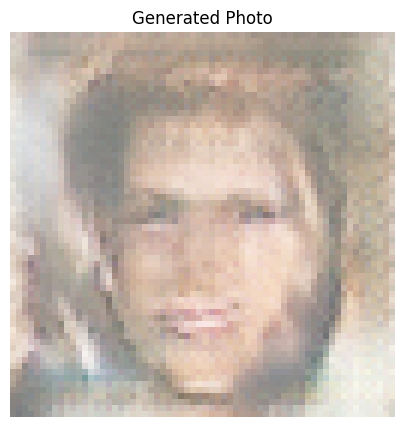

In [34]:
predict_new_sketch(filepath)

In [ ]:
def predict_new_sketch(og, inp):
    og_img = preprocess_image(og)             
    inp_img = preprocess_image(inp)            
    inp_batch = tf.expand_dims(inp_img, 0)               
    generated = cycle_gan.gen_G(inp_batch, training=False)[0].numpy()

    # denormalize generated from [-1,1] -> [0,1]
    generated = (generated * 0.5) + 0.5
    input_img = inp_img.numpy() 
    original_img = og_img.numpy()                      

    fig, axes = plt.subplots(1, 3, figsize=(8, 4))
    axes[0].imshow(original_img)
    axes[0].set_title("Original Photo")
    axes[0].axis("off")
    axes[1].imshow(input_img)
    axes[1].set_title("Input Sketch")
    axes[1].axis("off")
    axes[2].imshow(generated)
    axes[2].set_title("Generated Photo")
    axes[2].axis("off")
    plt.show()

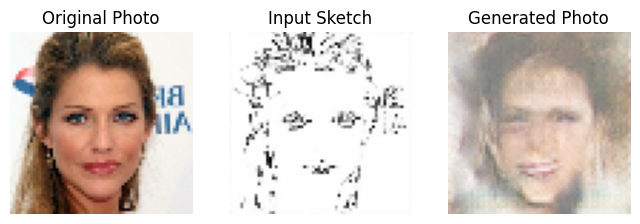

In [40]:
og_photo = 'dataset/val/photos/444.jpg'
input_photo='dataset/val/sketches/444.jpg'
predict_new_sketch(og_photo, input_photo)

### Visualizing the Cycle

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

def visualize_cycle(generator_F, generator_G, test_input, direction='AtoB'):
    # 1. Generate the Fake image
    fake_image = generator_F(test_input, training=False)
    
    # 2. Reconstruct the Original image (Cycle)
    reconstructed_image = generator_G(fake_image, training=False)
    
    # --- Plotting ---
    plt.figure(figsize=(12, 12))
    
    # Row 1: Original
    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(test_input[0] * 0.5 + 0.5) # Undo normalization (-1,1 -> 0,1)
    plt.axis('off')

    # Row 2: Fake (Translated)
    plt.subplot(1, 3, 2)
    plt.title(f"Translated ({direction})")
    plt.imshow(fake_image[0] * 0.5 + 0.5)
    plt.axis('off')

    # Row 3: Reconstructed
    plt.subplot(1, 3, 3)
    plt.title("Reconstructed Cycle")
    plt.imshow(reconstructed_image[0] * 0.5 + 0.5)
    plt.axis('off')
    
    plt.show()

Visualizing


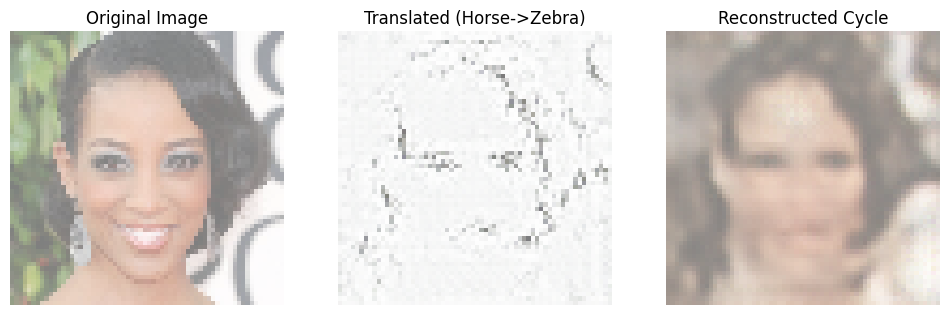

Visualizing


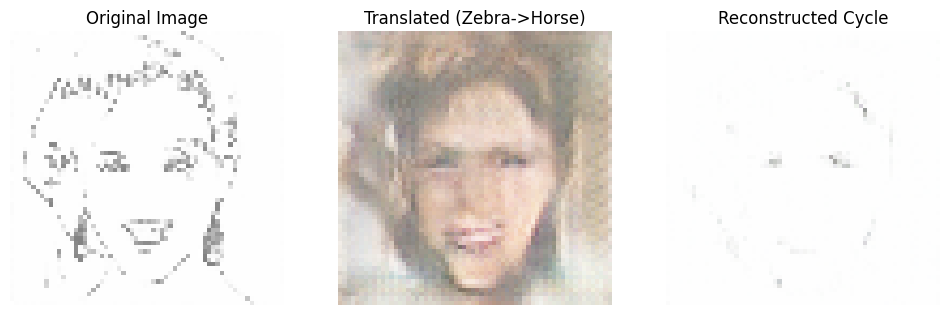

In [46]:
# 1. Get an iterator from your dataset
data_iterator = iter(train_dataset) # Replace 'train_dataset' with your actual dataset variable name

# 2. Extract the next batch
# CycleGAN datasets usually return a tuple (domain_A_images, domain_B_images)
sample_horse_batch, sample_zebra_batch = next(data_iterator)

# 3. Now you can run the visualization
print("Visualizing")
visualize_cycle(gen_F, gen_G, sample_horse_batch, direction='Horse->Zebra')

print("Visualizing")
visualize_cycle(gen_G, gen_F, sample_zebra_batch, direction='Zebra->Horse')

## 9. Evaluation

In [17]:
import numpy as np
from scipy.linalg import sqrtm
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

def calculate_fid_score(real_images, fake_images, inception_model):
    # 1. Preprocess images for InceptionV3 (resize to 299x299, normalize)
    real_images = tf.image.resize(real_images, (299, 299))
    fake_images = tf.image.resize(fake_images, (299, 299))
    
    real_images = preprocess_input(real_images)
    fake_images = preprocess_input(fake_images)

    # 2. Get features (activations) from InceptionV3
    act1 = inception_model.predict(real_images)
    act2 = inception_model.predict(fake_images)

    # 3. Calculate Mean and Covariance
    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)

    # 4. Calculate Sum Squared Difference between means
    ssdiff = np.sum((mu1 - mu2)**2.0)

    # 5. Calculate Square Root of product of covariances
    covmean = sqrtm(sigma1.dot(sigma2))

    # Check for imaginary numbers (numerical instability)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    # 6. Final FID Score
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

In [18]:
# Load InceptionV3 only once (exclude top layers to get features)
inception = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))

In [8]:
from keras.models import load_model
import tensorflow as tf

gen_G = load_model('sketch_to_photo_generator.h5',
                   custom_objects={'InstanceNormalization': InstanceNormalization},
                   compile=False)

In [19]:
NUM_EVAL = 100
EVAL_BATCH = 10  # adjust to fit memory / speed

eval_ds = train_dataset.unbatch().take(NUM_EVAL).batch(EVAL_BATCH)

photos = []
sketches = []
for batch_photos, batch_sketches in eval_ds:
    photos.append(batch_photos)
    sketches.append(batch_sketches)

real_batch = tf.concat(photos, axis=0)[:NUM_EVAL]
input_batch = tf.concat(sketches, axis=0)[:NUM_EVAL]

# Generate fake images
fake_batch = gen_G(input_batch, training=False)

print(f"Calculating FID Score on {NUM_EVAL} samples...")
fid_score = calculate_fid_score(real_batch, fake_batch, inception)
print(f"FID Score: {fid_score}")

2025-11-25 12:30:19.876611: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Calculating FID Score on 100 samples...
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
FID Score: 0.6112794663349483
FID Score: 0.6112794663349483


/var/folders/52/cdp4_l0n12d9kcjj_bqgm1x00000gn/T/ipykernel_24783/3146619936.py:25: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma1.dot(sigma2))


## 10. Conclusion & Key Findings

This project implemented a CycleGAN in TensorFlow to translate unpaired face sketches into realistic photographs. Using adversarial and cycle-consistency losses, the model learned sketch-to-photo translation without requiring paired data.

CycleGAN successfully performed unpaired image translation, generating photo-like outputs that preserved facial structure and details. Quantitative evaluation using FID scores confirmed the realism and diversity of the generated images. The use of InstanceNormalization was essential for stable training and sharper outputs, while batch-based FID evaluation allowed fast and reproducible quality assessment. The model also generalized well to new sketches, producing visually convincing results.

Overall, this work demonstrates CycleGAN’s strength in bridging visual domains using unpaired datasets and highlights its potential for tasks such as artistic style transfer, data augmentation, and digital image restoration.